![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import numpy as np

In [6]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [7]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [8]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [10]:
# Función de varianza
def varianza(y):
    if y.shape[0] == 0:
        return 0
    else:
        return np.var(y)

# Función de ganancia por varianza
def varianza_impurity(X_col, y, split):
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    var_total = varianza(y)
    var_l = varianza(y_l)
    var_r = varianza(y_r)

    impurity = var_total - (n_l / (n_l + n_r) * var_l + n_r / (n_l + n_r) * var_r)

    return impurity

# Mejor split
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]

    for j in features:
        X_col = X.iloc[:, j].astype(float)
        if X_col.nunique() <= 1:
            continue
        try:
            percentiles = np.arange(0, 100, 100.0 / num_pct).tolist()
            splits = np.percentile(X_col, percentiles)
            splits = np.unique(splits)
            for split in splits:
                gain = varianza_impurity(X_col, y, split)
                if gain > best_split[2]:
                    best_split = [j, split, gain]
        except:
            continue

    return best_split

# Crecimiento del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    if X.shape[0] == 1:
        dt = dict(y_pred=y.iloc[0], level=level, split=-1, n_samples=1, gain=0)
        return dt

    j, split, gain = best_split(X, y, num_pct)
    y_pred = y.mean()

    dt = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)

    if gain < min_gain:
        return dt
    if max_depth is not None and level >= max_depth:
        return dt

    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    dt['split'] = [j, split]
    dt['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    dt['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)

    return dt

# Predicción del árbol
def tree_predict(X, dt):
    predicted = np.ones(X.shape[0])

    if dt['split'] == -1:
        predicted = predicted * dt['y_pred']
    else:
        j, split = dt['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, dt['sr'])
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, dt['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, dt['sl'])
            predicted[~filter_l] = tree_predict(X_r, dt['sr'])

    return predicted

# Entrenamiento del árbol
dt = tree_grow(X_train, y_train, level=0, min_gain=0.001, max_depth=3, num_pct=10)

# Predicción en test
y_pred_dt = tree_predict(X_test, dt)

# Métricas
MSE_DT = mean_squared_error(y_test, y_pred_dt)
RMSE_DT = np.sqrt(MSE_DT)
MAE_DT = mean_absolute_error(y_test, y_pred_dt)

print(f"MSE árbol manual: {MSE_DT:.2f}")
print(f"RMSE árbol manual: {RMSE_DT:.2f}")
print(f"MAE árbol manual: {MAE_DT:.2f}")


MSE árbol manual: 3718730.97
RMSE árbol manual: 1928.40
MAE árbol manual: 1454.14


### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [12]:
# Celda 2
np.random.seed(123)

# Creación y uso de muestras
n_samples = X_train.shape[0]
n_B = 10
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_B + 1)]

# Creación de árboles de decisión
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# Predicciones
y_pred = pd.DataFrame(index=X_test.index, columns=[list(range(n_B))])

for i, sample in enumerate(samples):
    X_train_B = X_train.iloc[sample, :]
    y_train_B = y_train.iloc[sample]
    treereg.fit(X_train_B, y_train_B)
    y_pred.iloc[:, i] = treereg.predict(X_test)

# Evaluación
# Error para cada árbol
for i in range(n_B):
    print('Modelo ', i, 'tiene un error: ', np.sqrt(mean_squared_error(y_pred.iloc[:, i], y_test)))

# Predicciones promedio
y_pred.mean(axis=1)

# Error promedio
MSE_bagging = mean_squared_error(y_pred.mean(axis=1), y_test)
RMSE_bagging = np.sqrt(MSE_bagging)

print(f'MSE Bagging Manual: {MSE_bagging}')
print(f'RMSE Bagging Manual: {RMSE_bagging}')

Modelo  0 tiene un error:  2141.613353645869
Modelo  1 tiene un error:  2136.3519863123465
Modelo  2 tiene un error:  2122.718759132052
Modelo  3 tiene un error:  2087.278992468617
Modelo  4 tiene un error:  2168.518742842026
Modelo  5 tiene un error:  2113.8811455834793
Modelo  6 tiene un error:  2127.933470769012
Modelo  7 tiene un error:  2184.414847251443
Modelo  8 tiene un error:  2138.1071697514985
Modelo  9 tiene un error:  2132.097520859104
MSE Bagging Manual: 3227180.817664935
RMSE Bagging Manual: 1796.4355868399332


### Desempeño bagging manual

1. Los errores de cada modelo individual están en el rango de aproximadamente 2087.28 a 2184.41. Esto indica que todos los modelos individuales tienen un rendimiento similar, aunque hay cierta variabilidad. El modelo con mejor rendimiento tiene un error de 2087.28, mientras que el modelo con peor rendimiento tiene un error de 2184.41.
2. El error cuadrático medio (MSE) del modelo combinado es 3'227,180.82 y su raíz cuadrada (RMSE) es 1796.44, lo que indica que en este modelo el precio predicho del automovil estará equivocado en 1796.44 ya sea para arriba o para abajo.
3. El RMSE del modelo ensamble (1796.44) es menor que los errores individuales de cada modelo, lo cual es esperado en un modelo de bagging. Esto es positivo, pues sugiere que el ensamble ha reducido efectivamente la varianza que podría estar presente en los modelos individuales.

### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [15]:
# Celda 3
n_features = X.shape[1]
max_features = int(np.log(n_features))
max_features = max(1, max_features)

bagreg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=10, max_features=max_features,
                          bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred = bagreg.predict(X_test)

MSE_bagging2 = mean_squared_error(y_test, y_pred)
RMSE_bagging2 = np.sqrt(MSE_bagging2)

print(f'MSE Bagging: {MSE_bagging2}')
print(f'RMSE Bagging: {RMSE_bagging2}')

MSE Bagging: 7134309.371437651
RMSE Bagging: 2671.0127988157697


### Desempeño bagging con librería

1. El error cuadrático medio (MSE) del modelo bagging çon librería es 7'234.309 y su raíz cuadrada (RMSE) es 2.671, lo que indica que en este modelo el precio predicho del automovil estará equivocado en 2671 ya sea para arriba o para abajo. Estos valores son significativamente mayores que los obtenidos con el modelo de bagging manual.
2. La diferencia de los valores de error del modelo de bagging con librería y el manual podría explicarse al cambio en el parámetro max_depth, ya que al limitarlo usando el log de n_features se puede estar limitando la capacidad de cada árbol para aprender patrones complejor entre las variables, al considerar menos características.


### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [18]:
# Celda 4
# Creación del modelo
rfreg = RandomForestRegressor(random_state=1)

# Entrenamiento
rfreg.fit(X_train, y_train)

# Predicciones
y_pred = rfreg.predict(X_test)

# Evaluación
MSE_rfreg = mean_squared_error(y_test, y_pred)
RMSE_rfreg = np.sqrt(MSE_rfreg)

print(f'MSE Random Forest: {MSE_rfreg}')
print(f'RMSE Random Forest: {RMSE_rfreg}')

MSE Random Forest: 3083089.1739264703
RMSE Random Forest: 1755.8727670097485


### Desempeño random forest

1. El error cuadrático medio (MSE) del modelo random forest es 3'083.089 y su raíz cuadrada (RMSE) es 1.755,8, lo que indica que en este modelo el precio predicho del automovil estará equivocado en 1.755,9 ya sea para arriba o para abajo. Estos valores son significativamente mayores que los obtenidos con el modelo de bagging manual.
2. Es importante resaltar que este modelo puede ser mejorado ajustando hiperparámetros, ya que en este caso se hizo un modelo con los predeterminados por la función `RandomForestRegressor`.

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [21]:
# Celda 5
rf = RandomForestRegressor()
parametros_rf = {
    'max_depth': [5, 10, 20, 30, 50, None],
    'max_features': ['auto', 'sqrt', 'log2'],
    'n_estimators': [50, 100, 200, 300, 400]
}

mejoras_rf = GridSearchCV(estimator=rf, param_grid=parametros_rf,
                              scoring='neg_mean_squared_error', cv=3, n_jobs=-1, verbose=1)

mejoras_rf.fit(X_train, y_train)

mejorMod_rf = mejoras_rf.best_estimator_
y_pred_rf_mejor = mejorMod_rf.predict(X_test)
mse_rf_mejor = mean_squared_error(y_test, y_pred_rf_mejor)
rmse_rf_mejor = np.sqrt(mse_rf_mejor)

print("Mejores hiperparámetros:", mejoras_rf.best_params_)
print(f'MSE del mejor modelo Random Forest: {mse_rf_mejor}')
print(f"RMSE del mejor modelo Random Forest: {rmse_rf_mejor}")


Fitting 3 folds for each of 90 candidates, totalling 270 fits
Mejores hiperparámetros: {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 400}
MSE del mejor modelo Random Forest: 2441934.9940533484
RMSE del mejor modelo Random Forest: 1562.6691889371045


### Desempeño Random Forest calibrado

- El modelo calibrado de Random Forest obtuvo un **MSE de 2'441,935** y un **RMSE de 1,562.67**, lo que representa una mejora importante frente al modelo base de Random Forest (MSE: 3'083,089 | RMSE: 1,755.80). Esto indica que, en promedio, el error al predecir el precio del automóvil se redujo en aproximadamente 193 unidades monetarias.
  
- Esta mejora refleja el impacto positivo del ajuste de hiperparámetros, ya que se encontró una combinación más efectiva para la estructura y diversidad de los árboles dentro del ensamble.

- Los **mejores hiperparámetros encontrados** fueron:  
  - `max_depth = 10`: limita la profundidad de cada árbol, lo cual ayuda a evitar el sobreajuste. Una profundidad moderada permite capturar patrones relevantes sin memorizar ruido.  
  - `max_features = 'sqrt'`: selecciona aleatoriamente una fracción de variables en cada división, lo que promueve la diversidad entre árboles y mejora la generalización del modelo.  
  - `n_estimators = 400`: usar una mayor cantidad de árboles mejora la estabilidad de las predicciones al reducir la varianza del modelo.

- En conjunto, estos ajustes muestran cómo un **control adecuado de complejidad (`max_depth`)**, una **selección estratégica de variables (`max_features`)** y un **mayor tamaño del ensamble (`n_estimators`)** pueden mejorar notablemente el desempeño del modelo.


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [23]:
!pip install xgboost

In [24]:
# Celda 6
from xgboost import XGBRegressor
XG_Boost = XGBRegressor()
XG_Boost.fit(X_train, y_train)
y_predXG = XG_Boost.predict(X_test)
MSE_XGB = mean_squared_error(y_test, y_predXG)
RMSE_XGB = np.sqrt(MSE_XGB)
print(f'MSE XGBoost: {MSE_XGB}')
print(f'RMSE XGBoost: {RMSE_XGB}')

MSE XGBoost: 2576781.0
RMSE XGBoost: 1605.2354967418332


### Desempeño XGBoost

1. El error cuadrático medio (MSE) del modelo obtenido con XGBoost es de 2'576.781,07 que es un valor bastante mejor que el de casi todos los modelos anteriores donde podemos ver que esta métrica no baja de 3 millones el MSE a excepción del Random Forest calibrado. Luego, tenemos el RMSE que es de 1.605,24 así que la estimación de este modelo puede equivocarse en el precio del carro +- ese valor para la regresión del precio de carros. 
2. En el siguiente punto se muestra cómo se puede mejorar aún más el modelo y calibrar los parámetros relevantes para que nos permita tener un modelo más preciso en la estimación. 

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [28]:
xgb = XGBRegressor()

parametros = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0],
    'gamma': [0, 0.5, 1, 2, 5, 10],
    'colsample_bytree': [0.3, 0.5, 0.7, 1.0],
}

mejoras = GridSearchCV(estimator=xgb, param_grid=parametros,
                       scoring='neg_mean_squared_error',
                       cv=3, verbose=1, n_jobs=-1)

mejoras.fit(X_train, y_train)

mejorMod = mejoras.best_estimator_

y_pred_mejorXGB = mejorMod.predict(X_test)
mse_mejorXGB = mean_squared_error(y_test, y_pred_mejorXGB)
rmse_mejorXGB = np.sqrt(mse_mejorXGB)

print("Mejores parámetros:", mejoras.best_params_)
print(f'MSE del mejor modelo XGBoost: {mse_mejorXGB}')
print(f"RMSE del mejor modelo XGBoost: {rmse_mejorXGB}")


Fitting 3 folds for each of 192 candidates, totalling 576 fits
Mejores parámetros: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.05}
MSE del mejor modelo XGBoost: 2387044.25
RMSE del mejor modelo XGBoost: 1545.006229760903


### Resultados XGBoost - Post Calibración

1. Del modelo incial disminuimos tanto el MSE como el RMSE, teniendo un error de +- 1.546,23 en la estimación de los precios de los carros y un MSE de 2'390.838,79. El RMSE es más pequeño por 60 USD, lo que es una mejora significativa frente al primer modelo realizado con XGBoost sin calibrar; es decir, la calibración fue exitosa y tenemos un modelo con una mejor predicción. 

2. En cuanto a los parámetros que se calibraron, tenemos el colsample_bytree que nos quedó un 0,7, es decir un 70% de las características que tenemos disponibles para la predicción se usan en cada árbol; así, podemos crear un modelo más robusto e intentar evitar el sobreajuste. Luego, tenemos gamma, que en esta ocasión nos dio 0 lo que puede volver nuestro modelo más complejo y con divisiones adicionales en los árboles; no siempre será el valor óptimo pues simplificar los árboles del modelo (aumentar el gamma) puede también reducir el overfitting y regularizar, una de las características que agrega valor al XGBoost. Por último, tenemos el learning_rate que nos quedó de 0,05 que como su nombre lo dice es la "velocidad" a la que el modelo aprende, valores más bajos como el que nos dio es una velocidad más lenta por lo que el modelo aprende gradualmente y esto a pesar de requerir más iteraciones también puede significar menos overfitting. En general, según los parámetros tenemos que hay dos que nos ayudan a contrarestar el sobreajuste que podemos estar generando al tener gamma en 0. 

### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [33]:
# Celda 8
print(f'MSE Random Forest: {MSE_rfreg}')
print(f'RMSE Random Forest: {RMSE_rfreg}')
print(f'MSE del mejor modelo Random Forest: {mse_rf_mejor}')
print(f"RMSE del mejor modelo Random Forest: {rmse_rf_mejor}")
print(f'MSE XGBoost: {MSE_XGB}')
print(f'RMSE XGBoost: {RMSE_XGB}')
print(f'MSE del mejor modelo XGBoost: {mse_mejorXGB}')
print(f"RMSE del mejor modelo XGBoost: {rmse_mejorXGB}")

MSE Random Forest: 3083089.1739264703
RMSE Random Forest: 1755.8727670097485
MSE del mejor modelo Random Forest: 2441934.9940533484
RMSE del mejor modelo Random Forest: 1562.6691889371045
MSE XGBoost: 2576781.0
RMSE XGBoost: 1605.2354967418332
MSE del mejor modelo XGBoost: 2387044.25
RMSE del mejor modelo XGBoost: 1545.006229760903


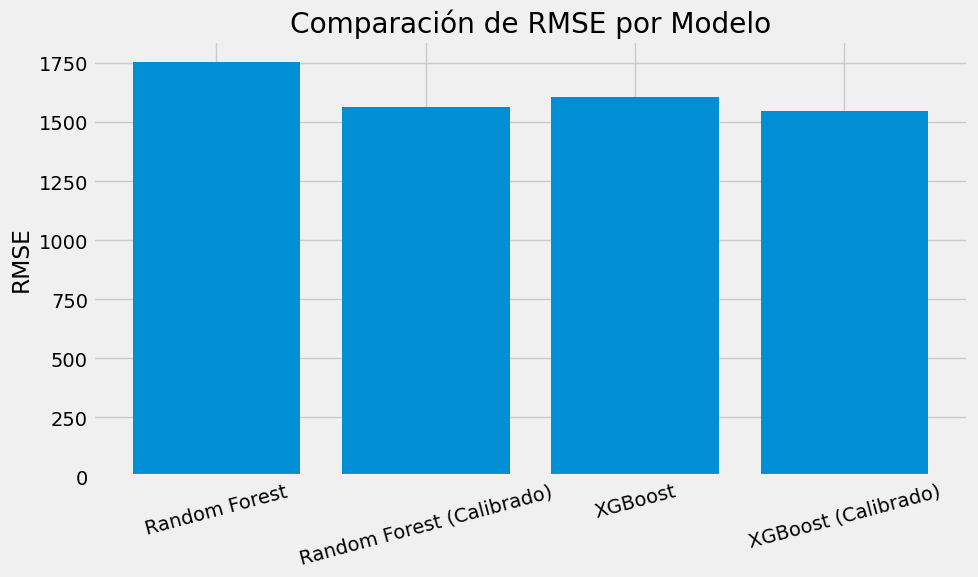

In [68]:
import matplotlib.pyplot as plt

modelos = [
    'Random Forest',
    'Random Forest (Calibrado)',
    'XGBoost',
    'XGBoost (Calibrado)'
]

rmse_valores = [
    RMSE_rfreg,
    rmse_rf_mejor,
    RMSE_XGB,
    rmse_mejorXGB
]

# Gráfico
plt.figure(figsize=(10, 6))
plt.bar(modelos, rmse_valores)
plt.ylabel('RMSE')
plt.title('Comparación de RMSE por Modelo')
plt.xticks(rotation=15)
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()

### Comparación y análisis de resultados

- Al comparar los resultados obtenidos con los distintos modelos, el **mejor desempeño lo tiene el modelo calibrado de XGBoost**, que logró un **MSE de 2'387,044.25** y un **RMSE de 1,545.01**. Esto lo convierte en el modelo más preciso para predecir el precio de los automóviles dentro de los modelos evaluados.

- En contraste, el **modelo base de Random Forest (sin calibrar)** presentó el **peor desempeño**, con un **MSE de 3'083,089.17** y un **RMSE de 1,755.87**. Esta diferencia representa un error adicional promedio de más de 200 unidades monetarias por predicción respecto al modelo XGBoost calibrado.

- Las **ventajas del modelo XGBoost calibrado** incluyen:
  - Un mejor ajuste a los datos gracias a una calibración fina de hiperparámetros como `learning_rate`, `gamma` y `colsample_bytree`.
  - Un proceso de aprendizaje más gradual (`learning_rate=0.05`) que permite generalizar mejor sin sobreajustarse.
  - Uso eficiente de las variables (`colsample_bytree=0.7`) para generar diversidad en los árboles del ensamble.
  - Un diseño flexible que puede adaptarse bien a la complejidad del problema.

- Por otro lado, las **desventajas del modelo Random Forest sin calibrar** son:
  - El uso de hiperparámetros por defecto, que pueden no ser ideales para este conjunto de datos.
  - Falta de control sobre la profundidad de los árboles y la selección de variables, lo cual puede resultar en un modelo menos ajustado o con mayor varianza.
  - A pesar de ser un modelo robusto, no logró igualar la precisión de XGBoost en este caso.

- En conclusión, la calibración de hiperparámetros fue clave para mejorar el desempeño de ambos modelos, pero **XGBoost calibrado se destacó como el mejor predictor del precio de los automóviles**, combinando buena precisión y control del sobreajuste.
